<div style="border:solid green 2px; padding: 20px">

**Hello Kemi,**

My name is **John Dickson** (https://hub.tripleten.com/u/13efa053) and today I'll be reviewing your project!

You’ll find specific notes inside the project file, marked green, yellow or red.


**Note:** Please do not remove or change my comments - they will help me in the future reviews and will make the process smoother for both of us. 

<div class="alert alert-success"; style="border-left: 7px solid green">
<b>✅ Reviewer's comment</b> 
    
Such comment will mark efficient solutions and good ideas that can be used in other projects. It will also point at the document formatting, comments, and analysis. 
</div>

<div class="alert alert-warning"; style="border-left: 7px solid gold">
<b>⚠️ Reviewer's comment</b> 
    
The parts marked with yellow comments indicate that there is room for optimisation. Though the correction is not necessary it is good if you implement it.
</div>

<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment</b> 
    
If you see such a comment, it means that there is a problem that needs to be fixed. Please note that I won't be able to accept your project until the issue is resolved.
</div>

---
    
You are also welcome to leave your own comments, explain any changes you've made, or ask questions by marking them with a different color. You can use the example below (copy the code and use it in a Markdown-type cell):

```
    
<div class="alert alert-info"; style="border-left: 7px solid blue">
<b>Student’s Comment</b>

```
    
It will appear like this:
    
<div class="alert alert-info"; style="border-left: 7px solid blue">
<b>Student’s Comment</b></div>
</div>

<div style="border:solid Purple 2px; padding: 20px">

<div style="border: 2px solid Green; padding: 5px; margin: 5px">
 
**What Was Great:**

- You were able to do the initial data exploration well
- 2 methods of dealing with imbalance were used
- Models were tuned
- different models were used
- Data was split into 3 sets

</div>
<div style="border: 2px solid red; padding: 5px; margin: 5px">

**What could be improved:**

- Make sure to write the expected findings, there should be findings in each section and at the end.
- Ensure the model is more balanced after upsampling
- Use the test set only at the end
</div>

---

Great work Kemi! You have done well with this project! I was particularly impressed with checking and preprocessing the data. There are a couple of small things that can be done to improve, but I am confident you can have them fixed for next time. 

<div style="border:solid green 2px; padding: 20px"> <h1 style="color:green; margin-bottom:20px">Reviewers comment v2</h1>

Hello Kemi!

I'm happy to review your project today 🙌

My name is **Justino Imbert** ([this](https://hub.tripleten.com/u/125e88ae) is my Hub profile) and today I'll be reviewing your project!


You can find my comments under the heading **«Review»**. I will categorize my comments in green, blue or red boxes like this:

<div class="alert alert-success">
    <b>Success:</b> if everything is done successfully
</div>
<div class="alert alert-warning">
    <b>Remarks:</b> if I can give some recommendations or ways to improve the project
</div>
<div class="alert alert-danger">
    <b>Needs fixing:</b> if the block requires some corrections. Work cant be accepted with the red comments
</div>

Please dont remove my comments :) If you have any questions dont hesitate to respond to my comments in a different section. 
<div class="alert alert-info"> <b>Student comments:</b> For example like this</div>   


<div class="alert alert-block alert-info">
<b>Reviewer's comment v2:</b> </a>

Amazing job with this submission! I'm approving this project!

Congrats and I wish you the best of luck in the following sprints!

Looking forward to reviewing your future work!
    
</div>


# Report on the prediction of Beta Bank customers

# Introduction
The report below shows the likelihood that the Beta Bank customer will leave the bank soon.
The data on clients' past behaviours and termination of contract  with the bank was loaded and cleaned. The Tenure has about 909, which was replaced with the median because it represents the customers' experience. The first three rows were removed because they are unique identifiers and not useful for the prediction. The gender and the geography are objects that need to be translated to numbers for the machine learning model to understand. The Ordinal encoder is not necessary because  the features are in numerical format. The confusion matrix was analysed to  gain insight of the class imbalance, analyze how many  churners your model correctly identified (True Positives), how many actual churners your model missed (False Negatives), and how many loyal customers your model incorrectly flagged as churners (False Positives). The class imbalance shows that about 80% stayed, and about 20% customers left.  and the fi_score was also analysed using the test set

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
churn = pd.read_csv('/datasets/Churn.csv')


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score


In [3]:
churn.head()

# The first 5 rows of the data to understand the data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


In [4]:
churn.shape
# The data has 10000 rows and 14 columns

(10000, 14)

In [5]:
churn.duplicated().sum()
# This shows there are no duplicated data

0

In [6]:
churn.info()
# This shows that there are total of 14 columns, the georgraphy and Gender are objects 
# others are integers and float.
# The RowNumber, Customer ID Surname  are not useful for this analysis so they would be removed becasue they are identifier

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


In [7]:
churn_clean = churn.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
churn_clean.head()
# The first 3 rows have been dropped

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


In [8]:
churn_clean.isnull().sum()
# The Tenure which is a float has 909 missing values

CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure             909
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64

In [9]:
churn_clean['Tenure'].describe()
# min and max years is 0 to 10 years, Mean is 4.998 and median (50%) is 5 years 
# 25% of customer has tenur fewer than 2 years , while 75% have 7 years
# customers tenure is between 3 to 7 years
# Mean and median are approximately 5, which suggests the distribution is roughly symmetric

count    9091.000000
mean        4.997690
std         2.894723
min         0.000000
25%         2.000000
50%         5.000000
75%         7.000000
max        10.000000
Name: Tenure, dtype: float64

In [10]:
churn_clean.shape
# The data now has 11 columns and 10,000

(10000, 11)

array([[<AxesSubplot:title={'center':'Tenure'}>]], dtype=object)

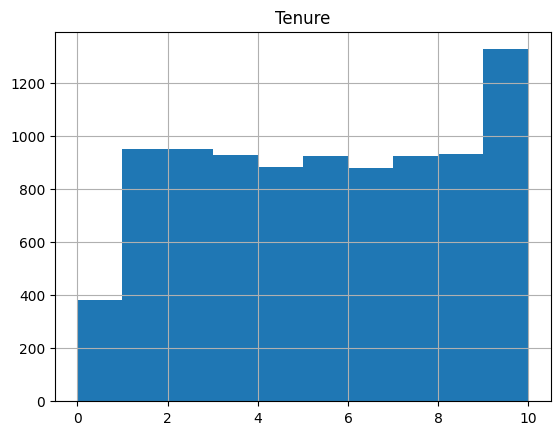

In [11]:
# addressing the missing value
churn.hist('Tenure')

In [12]:
churn_clean['Tenure'].fillna(churn_clean['Tenure'].median(), inplace=True)
# filling the missing values with median for the missing Tenure values because the tenure data is roughly symmetric distribution
# mean can be influenced by a few long term customers while median represents the typical customer expereince


<div class="alert alert-success"; style="border-left: 7px solid green">
<b>✅ Reviewer's comment V1</b> 
    
Good! It is important to explain your reasoning when making such an important choice for filling data. 
</div>

In [13]:
churn_clean.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [14]:
churn_clean_ohe = pd.get_dummies(churn_clean, drop_first=True)
# Translation of objects to number and removal of one column to avoid redundancy

In [15]:
# The below gives the number of rows and columns  for the train and valid models
target = churn_clean_ohe['Exited']
features = churn_clean_ohe.drop('Exited', axis=1)

features_train, features_valid, target_train, target_valid = train_test_split(
    features, target, test_size=0.20, random_state=12345
)

print(features_train.shape)
print(features_valid.shape)
print(target_train.shape)
print(target_valid.shape)


(8000, 11)
(2000, 11)
(8000,)
(2000,)


In [16]:
print(features_train.columns)

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='object')


In [17]:
# spliting the test into half

features_valid, features_test, target_valid, target_test = train_test_split(features_valid, target_valid, test_size =0.5, random_state =12345)
print(features_test.shape)
print(features_valid.shape)
print(target_test.shape)
print(target_valid.shape)



(1000, 11)
(1000, 11)
(1000,)
(1000,)


<div class="alert alert-success"; style="border-left: 7px solid green">
<b>✅ Reviewer's comment V1</b> 
    
Data is split into 3 sets. 
</div>

In [18]:
#Ordinal encoder is not necessary because  the features are in numerical format for machine learning

In [19]:
# Evaluating a decision tree model.  Decision Tree model correctly predicted customer behavior 78.3% of the time. 
model = DecisionTreeClassifier(random_state=12345)
model.fit(features_train, target_train)
predicted_valid = model.predict(features_valid)
accuracy_valid = accuracy_score(target_valid, predicted_valid)

print(accuracy_valid)



0.778


In [20]:
print(confusion_matrix(target_valid, predicted_valid))

[[660 115]
 [107 118]]


Looking at the confusion matrix, 676 is the true negative, model correctly predicted No churn, and the customer actually didn't churn. This number represents the customers that are staying the top right (107) model predicted yes churn but the customer actually didn't churn. The bottom left (115) is the false negative, no churn, but the customer did churn. These customers could be lost completely and lastly  the bottom-right (102) which is true positive model predicted yes churn and the customer actually did churn.

In [21]:
print(f1_score(target_valid, predicted_valid))


0.5152838427947598


F1 score ranges from 0 to 1, the DecisionTreeClassifier model result is 0.515, which is moderately effective at predicting churn but not up to the 0.59 requirement 

<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment V1</b> 
    
Test set should  be used once, on the best model with the best parameters at the end.
</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v2:</b> </a>

Awesome job!
    
</div>


In [22]:
# checking for imbalances
print(target.value_counts())
# the difference shows that there are imbalances in the target and the difference is severe

0    7963
1    2037
Name: Exited, dtype: int64


In [23]:

# using the logistic regression model, the f1 score is 0.49. The is below the requirement
model = LogisticRegression(random_state=12345, class_weight= 'balanced', solver='liblinear' )
model.fit(features_train, target_train)
predicted_valid = model.predict(features_valid)
print('F1:', f1_score(target_valid, predicted_valid))


F1: 0.49221183800623053


<div class="alert alert-success"; style="border-left: 7px solid green">
<b>✅ Reviewer's comment V1</b> 
    
class_weight is a valid method for dealing with class imbalance.
</div>

In [24]:
def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=12345
    )

    return features_upsampled, target_upsampled


features_upsampled, target_upsampled = upsample(
    features_train, target_train, 4
)

model = LogisticRegression(random_state=12345, solver='liblinear')
model.fit(features_upsampled, target_upsampled)
predicted_valid = model.predict(features_valid)
print('F1:', f1_score(target_valid, predicted_valid))
# with upsampling, the fi_score is 45% which is lower than the requirement using logistic regression

F1: 0.4546805349182764


In [25]:
print(target_upsampled.value_counts())
# before unsampling, the training data is heavily imbalanced. After unsampling and reaping 4 times, the samples are almost perfectly balanced


1    6440
0    6390
Name: Exited, dtype: int64


<div class="alert alert-success"; style="border-left: 7px solid green">
<b>✅ Reviewer's comment V1</b> 
    
Upsampling is one method of dealing with imbalance.
</div>

<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment V1</b> 
    
However, did we balance the classes or did we change the minority class?
</div>

In [31]:
# using randomforest classifier, the f1_score is slightly below the requirement of 0.61
model = RandomForestClassifier(random_state=12345)
model.fit(features_upsampled, target_upsampled)
predicted_valid = model.predict(features_valid)
print('F1:', f1_score(target_valid, predicted_valid))


F1: 0.6119402985074626


<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment V1</b> 
    
class weight and upsampling should not be used together for this project, when the classes are balanced class_weight has no effect. 
</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v2:</b> </a>

Excellent job!
    
</div>


In [28]:
# adding the class_weight = balanced using the randomforestclassification without upsampling also gave good f1_scores but slightly lower to the results with upsampling
estimator = [50,100,200]
depth = [2,5,8]
# to know which hyperparameter is the best for achieving the f1-score, so we create a for loop
for i in estimator:
    for j in depth:
        model = RandomForestClassifier(n_estimators = i, max_depth= j, class_weight= 'balanced', random_state=12345)
        model.fit(features_train, target_train)
        predicted_valid = model.predict(features_valid)
        print(f'F1:{f1_score(target_valid, predicted_valid)} n_estimators={i} max_depth = {j}')


F1:0.5784832451499118 n_estimators=50 max_depth = 2
F1:0.6222222222222222 n_estimators=50 max_depth = 5
F1:0.6545454545454547 n_estimators=50 max_depth = 8
F1:0.5704584040747029 n_estimators=100 max_depth = 2
F1:0.6263736263736264 n_estimators=100 max_depth = 5
F1:0.663983903420523 n_estimators=100 max_depth = 8
F1:0.5913043478260869 n_estimators=200 max_depth = 2
F1:0.6231884057971013 n_estimators=200 max_depth = 5
F1:0.6559999999999999 n_estimators=200 max_depth = 8


<div class="alert alert-success"; style="border-left: 7px solid green">
<b>✅ Reviewer's comment V1</b> 
    
Good to see some basic tuning. 
</div>

In [32]:
# analysing with  n_estimators=50 max_depth = 8, the test results shows 0.65
model = RandomForestClassifier(n_estimators = 50, max_depth= 8, class_weight= 'balanced', random_state=12345)
model.fit(features_train, target_train)
predicted_test = model.predict(features_test)

print(f'F1:{f1_score(target_test, predicted_test)} n_estimators={50} max_depth = {8}')

F1:0.6355555555555555 n_estimators=50 max_depth = 8


In [34]:
probabilities_test = model.predict_proba(features_test)
probabilities_one_test = probabilities_test[:, 1]

auc_roc = roc_auc_score(target_test, probabilities_one_test)

print(auc_roc)

0.8676890245415518


# Summary
The analysis shows logistic regression and class_weight F1 score is 0.49 while for random forest with  class_weight balanced f1_score is 0.63> The model was able to identify churners. This shows the combination of all customers predicted would churn and all customers who actually churned. This identifies  that 6-7 out of every 10 customers who are actually going to leave. The AUC_ROC value is 0.867  exceeds the requirement of 0.59. This measures how the model can distinguish between churners and non_churners

<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment V1</b> 
    
The F1 score is highly variable, we should use a larger test/validation test set or have a set randomstate to reduce variability. 

Is there a reason we are using the validation set instead of the test set here for auc_roc? 

We should have a conclusion here. 

</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v2:</b> </a>

Wonderful job!
    
</div>
